# Math LLM Probing & Evaluation Pipeline

This notebook implements a pipeline to:
1. Load `Qwen/Qwen2.5-Math-7B-Instruct`.
2. Generate answers to math problems (enforcing direct answers).
3. Extract hidden states.
4. Evaluate answers using Regex and SymPy.

In [1]:
import os
import sys

# 1. Clone the repo if it doesn't exist
REPO_NAME = "probing-llm-math"
if not os.path.exists(REPO_NAME):
    print("Cloning repository...")
    !git clone -b colab-pipeline-setup https://github.com/1hamzaiqbal/probing-llm-math.git
else:
    print(f"{REPO_NAME} already exists.")

# 2. Install dependencies
print("Installing dependencies...")
!pip install -q -r {REPO_NAME}/requirements.txt

# 3. Add to path so we can import src
if REPO_NAME not in sys.path:
    sys.path.append(REPO_NAME)

print("Setup complete!")

Cloning repository...
Cloning into 'probing-llm-math'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (146/146), done.
remote: Total 211 (delta 109), reused 153 (delta 58), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 1.34 MiB | 39.30 MiB/s, done.
Resolving deltas: 100% (109/109), done.
Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 7.5 MB/s eta 0:00:00
Setup complete!


In [2]:
try:
    from src import model_utils, evaluator
    print("Successfully imported modules from src.")
except ImportError as e:
    print(f"Error importing modules: {e}")
    print("Current path:", sys.path)
    print("Current dir contents:", os.listdir("."))
    if os.path.exists(REPO_NAME):
        print(f"{REPO_NAME} contents:", os.listdir(REPO_NAME))

Successfully imported modules from src.


In [3]:
# [OPTIONAL] Reset & Update
# Run this cell if you want to pull the latest code and free up VRAM without restarting the runtime.

import gc
import torch
import importlib
import sys

# 1. Free VRAM
print("Clearing VRAM...")
try:
    del model
    del tokenizer
except NameError:
    pass

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("VRAM cleared.")

# 2. Pull latest code
print("Pulling latest code...")
!cd {REPO_NAME} && git pull

# 3. Reload modules
print("Reloading modules...")
import src.model_utils
import src.evaluator
importlib.reload(src.model_utils)
importlib.reload(src.evaluator)
from src import model_utils, evaluator

print("Modules reloaded. You can now re-run the 'Load Model' cell.")

Clearing VRAM...
VRAM cleared.
Pulling latest code...
Already up to date.
Reloading modules...
Modules reloaded. You can now re-run the 'Load Model' cell.


In [4]:
# Load Model
# Use load_in_4bit=True for T4 GPUs to save VRAM and allow larger context
model, tokenizer = model_utils.load_model(model_name="Qwen/Qwen2.5-Math-7B-Instruct", load_in_4bit=True)

Loading model: Qwen/Qwen2.5-Math-7B-Instruct (4-bit: True)...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/161 [00:00<?, ?B/s]

In [5]:
# # Define some test questions (Weird Formats & Hard Problems)
# questions = [
#     # Matrix Determinant (LaTeX array check)
#     {"question": "Compute the determinant of the matrix $\\begin{pmatrix} 1 & 2 \\\\ 3 & 4 \\end{pmatrix}$.", "answer": "-2"},

#     # Interval Notation (Set theory)
#     {"question": "Find the domain of $f(x) = \\sqrt{x-1}$.", "answer": "[1, \\infty)"},

#     # Coordinates (Tuple format)
#     {"question": "Find the intersection point of the lines $y=x$ and $y=2-x$.", "answer": "(1, 1)"},

#     # Hard Integral (Gaussian - Symbol check)
#     {"question": "Evaluate $\\int_{-\\infty}^{\\infty} e^{-x^2} dx$.", "answer": "\\sqrt{\\pi}"},

#     # Hard Number Theory (AIME 2001 #1 - Integer answer)
#     {"question": "Find the sum of all positive integers $n$ such that $n$ divides $n^2 + 1$.", "answer": "1"},

#     # Nested Surds (Weird LaTeX)
#     {"question": "Simplify \\sqrt{3 + 2\\sqrt{2}}.", "answer": "1+\\sqrt{2}"},

#     # Units / Physics Style
#     {"question": "If a car travels 60 miles in 2 hours, what is its average speed in mph?", "answer": "30"},

#     # Multiple Choice Style (Letter extraction)
#     {"question": "Which of the following is prime? (A) 4 (B) 9 (C) 11 (D) 15. Answer with the letter only.", "answer": "C"}
# ]

In [6]:
# # Run Pipeline
# results = []

# for item in questions:
#     q = item["question"]
#     gt = item["answer"]

#     print(f"Processing: {q}")

#     # Generate
#     pred_text, hidden_states, is_truncated = model_utils.generate_answer(model, tokenizer, q)

#     # Check truncation
#     if evaluator.check_truncation(pred_text, is_truncated):
#         print("  WARNING: Output truncated!")

#     # Extract clean answer
#     clean_pred = evaluator.extract_answer(pred_text)

#     # Evaluate
#     is_correct = evaluator.is_equivalent(clean_pred, gt)

#     # print(f"  Pred: {pred_text}") # Commented out to reduce clutter if needed
#     print(f"  Clean: {clean_pred}")
#     print(f"  Correct: {is_correct}")

#     results.append({
#         "question": q,
#         "ground_truth": gt,
#         "prediction": pred_text,
#         "clean_prediction": clean_pred,
#         "correct": is_correct,
#         "truncated": is_truncated
#     })

In [7]:
# # Analyze Results
# correct_count = sum(1 for r in results if r['correct'])
# accuracy = correct_count / len(results)
# print(f"Accuracy: {accuracy:.2%}")

# Linear Probing

This section runs the linear probing experiments.
1. Collect hidden states and correctness labels from GSM8K.
2. Train a logistic regression classifier to predict correctness.
3. Visualize the results.

In [8]:
# # 1. Collect Data
# # We'll use the MATH dataset (all levels) and enforce balancing
# # to ensure we get both correct and incorrect answers.
# # Removing 'Level 5' filter to allow easier questions so we can find correct answers too.

# !python3 probing-llm-math/src/collect_probe_data.py --num_samples 5 --dataset math --balance --audit_file probe_audit.csv

In [9]:
# # [Optional] View Audit Log
# import pandas as pd
# if os.path.exists("probe_audit.csv"):
#     df_audit = pd.read_csv("probe_audit.csv")
#     display(df_audit.head(20))
#     print("\nClass Distribution:")
#     print(df_audit['is_correct'].value_counts())
# else:
#     print("Audit file not found.")

In [10]:
# SECOND MINI RUN
!python probing-llm-math/src/collect_probe_data.py \
    --num_samples 150 \
    --dataset math \
    --balance \
    --output_file probe_data.pt

Loading math dataset...
README.md: 3.93kB [00:00, 11.6MB/s]
algebra/train-00000-of-00001.parquet: 100% 505k/505k [00:01<00:00, 419kB/s]
algebra/test-00000-of-00001.parquet: 100% 353k/353k [00:00<00:00, 705kB/s]
Generating train split: 100% 1744/1744 [00:00<00:00, 60688.17 examples/s]
Generating test split: 100% 1187/1187 [00:00<00:00, 251002.71 examples/s]
number_theory/train-00000-of-00001.parqu(…): 100% 309k/309k [00:00<00:00, 619kB/s]
number_theory/test-00000-of-00001.parque(…): 100% 182k/182k [00:00<00:00, 367kB/s]
Generating train split: 100% 869/869 [00:00<00:00, 185337.65 examples/s]
Generating test split: 100% 540/540 [00:00<00:00, 177655.04 examples/s]
intermediate_algebra/train-00000-of-0000(…): 100% 575k/575k [00:00<00:00, 1.11MB/s]
intermediate_algebra/test-00000-of-00001(…): 100% 395k/395k [00:00<00:00, 801kB/s]
Generating train split: 100% 1295/1295 [00:00<00:00, 177393.90 examples/s]
Generating test split: 100% 903/903 [00:00<00:00, 183545.26 examples/s]
counting_and_pro

In [15]:
import pandas as pd

# Load the audit file
if os.path.exists("probe_audit.csv"):
    df_audit = pd.read_csv("probe_audit.csv")

    # Filter for incorrect predictions
    incorrect_predictions = df_audit[df_audit['is_correct'] == False]

    print("Displaying incorrect predictions for manual review:")
    # Display relevant columns for manual review
    display(incorrect_predictions[['question', 'ground_truth', 'clean_prediction']])

    if incorrect_predictions.empty:
        print("No incorrect predictions found in probe_audit.csv.")
else:
    print("Audit file 'probe_audit.csv' not found. Please ensure it has been generated.")

Displaying incorrect predictions for manual review:


,question,ground_truth,clean_prediction
3,"For the arithmetic sequence $1000, ~987, ~974,...",12,11
5,Express $555_{10}$ in base $5$.,4210_{5},4210_5
6,"If $a,b,c$ are positive integers less than $13...",5,6
10,Let $\mathbf{a}$ be a unit vector. Compute\n\...,2,\text{k} \times \text{k} = \text{0}
12,"A cube has a side length of $s,$ and its verti...",9,2
...,...,...,...
145,I draw a card from a standard 52-card deck. I...,\$15.48,\frac{12}{52}
146,"Let $a,$ $b,$ $c$ be positive real numbers suc...",28,1
147,Given $\mathbf{a} = \begin{pmatrix} 2 \\ 1 \\ ...,\begin{pmatrix} 6 \\ 3 \\ 0 \end{pmatrix},(\text{a} \times \text{b}) \times \text{c} - \...
148,Find the coordinates of one of the foci of the...,"(0,0)","(10, 0)"


No charts were generated by quickchart


In [16]:
# Load and analyze probe data
import torch
import pandas as pd
import numpy as np
from collections import Counter

# Load the data
data = torch.load("probe_data.pt")
print(f"Loaded {len(data)} samples")

# Basic stats
correct = sum(1 for d in data if d['is_correct'])
print(f"Correct: {correct}, Incorrect: {len(data) - correct}")

# Topic distribution
topics = Counter(d['topic'] for d in data)
print(f"\nTopic distribution: {dict(topics)}")

# Level distribution
levels = Counter(d['level_num'] for d in data)
print(f"Level distribution: {dict(sorted(levels.items()))}")

# Activation shapes
print(f"\nActivation shapes:")
print(f"  0%: {data[0]['activations_0pct'].shape}")
print(f"  50%: {data[0].get('activations_50pct', 'N/A')}")
print(f"  100%: {data[0]['activations_100pct'].shape}")

# Check for any issues
print(f"\nFirst few samples:")
for i, d in enumerate(data[:5]):
    print(f"  {i}: topic={d['topic']}, level={d['level_num']}, correct={d['is_correct']}")

Loaded 150 samples
Correct: 75, Incorrect: 75

Topic distribution: {'algebra': 87, 'precalculus': 27, 'counting_probability': 17, 'number_theory': 19}
Level distribution: {1: 12, 2: 27, 3: 30, 4: 36, 5: 45}

Activation shapes:
  0%: torch.Size([29, 3584])
  50%: tensor([[-2.8564e-02,  3.7354e-02, -1.9409e-02,  ...,  3.2196e-03,
          1.2207e-02,  2.0508e-02],
        [-3.9624e-01, -6.4209e-02, -6.0254e-01,  ..., -3.7231e-01,
          2.2705e-01,  8.0078e-02],
        [-4.3140e-01, -4.1333e-01, -5.2832e-01,  ..., -3.6938e-01,
          2.2119e-01,  2.2070e-01],
        ...,
        [ 6.6094e+00,  6.5039e+00, -1.3469e+01,  ..., -1.2773e+01,
         -1.8516e+00,  3.6328e+00],
        [ 1.1648e+01, -4.2969e-02, -9.1719e+00,  ..., -8.8359e+00,
          8.1055e-01,  6.1016e+00],
        [ 1.7705e+00,  3.8544e-02, -6.8652e-01,  ..., -1.6289e+00,
         -1.5503e-01,  5.0000e-01]], dtype=torch.float16)
  100%: torch.Size([29, 3584])

First few samples:
  0: topic=algebra, level=2, corr

In [17]:
# Check for potential evaluator false negatives
import re

df = pd.read_csv("probe_audit.csv")

print("Potential evaluator issues (wrong predictions that look close):")
print("="*60)

issues = []
for idx, row in df.iterrows():
    gt = str(row['ground_truth']).strip()
    pred = str(row['clean_prediction']).strip()

    if row['is_correct'] == False:
        # Check for formatting differences that should be equivalent
        gt_clean = re.sub(r'[_{}\\]', '', gt.lower())
        pred_clean = re.sub(r'[_{}\\]', '', pred.lower())

        if gt_clean == pred_clean:
            issues.append((idx, gt, pred, "Formatting mismatch"))
        elif gt.replace(" ", "") == pred.replace(" ", ""):
            issues.append((idx, gt, pred, "Whitespace mismatch"))
        # Check numeric close matches
        try:
            gt_num = float(gt)
            pred_num = float(pred)
            if abs(gt_num - pred_num) < 0.01:
                issues.append((idx, gt, pred, "Numeric near-match"))
        except:
            pass

print(f"Found {len(issues)} potential issues:")
for idx, gt, pred, issue_type in issues[:10]:
    print(f"  Row {idx}: GT='{gt}' vs Pred='{pred}' ({issue_type})")

Potential evaluator issues (wrong predictions that look close):
Found 2 potential issues:
  Row 5: GT='4210_{5}' vs Pred='4210_5' (Formatting mismatch)
  Row 93: GT='4210_{7}' vs Pred='4210_7' (Formatting mismatch)


In [18]:
# Save to Google Drive (run this if you want to persist)
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

# Create output directory
output_dir = "/content/drive/MyDrive/probe_results"
os.makedirs(output_dir, exist_ok=True)

# Copy files
shutil.copy("probe_data.pt", f"{output_dir}/probe_data.pt")
shutil.copy("probe_audit.csv", f"{output_dir}/probe_audit.csv")

print(f"Saved to {output_dir}")

Mounted at /content/drive
Saved to /content/drive/MyDrive/probe_results


In [22]:
# Train all probes on the collected data
!python probing-llm-math/src/train_probe.py \
    --data_file probe_data.pt \
    --output_dir probe_results

Loading data from probe_data.pt...
Loaded 150 samples
Num layers: 29, Hidden dim: 3584
Topics: ['algebra', 'precalculus', 'number_theory', 'counting_probability']
Levels: [1, 2, 3, 4, 5]
Has 50% checkpoints: True

TRAINING SUCCESS PROBES
Class balance: 75 correct, 75 incorrect

--- 0pct checkpoint ---
/content/probing-llm-math/src/train_probe.py:82: RuntimeWarning: invalid value encountered in divide
  w = w / w_norm  # Normalize
  Layer 0: LogReg=0.500, DiffMeans=0.500
  Layer 5: LogReg=0.500, DiffMeans=0.633
  Layer 10: LogReg=0.533, DiffMeans=0.667
  Layer 15: LogReg=0.467, DiffMeans=0.600
  Layer 20: LogReg=0.667, DiffMeans=0.667
  Layer 25: LogReg=0.633, DiffMeans=0.567
  LogReg Best: Layer 22 = 0.767
  DiffMeans Best: Layer 6 = 0.667

--- 50pct checkpoint ---
  Layer 0: LogReg=0.400, DiffMeans=0.467
  Layer 5: LogReg=0.500, DiffMeans=0.633
  Layer 10: LogReg=0.533, DiffMeans=0.500
  Layer 15: LogReg=0.633, DiffMeans=0.633
  Layer 20: LogReg=0.667, DiffMeans=0.633
  Layer 25: LogR


control_task_shuffled.png:


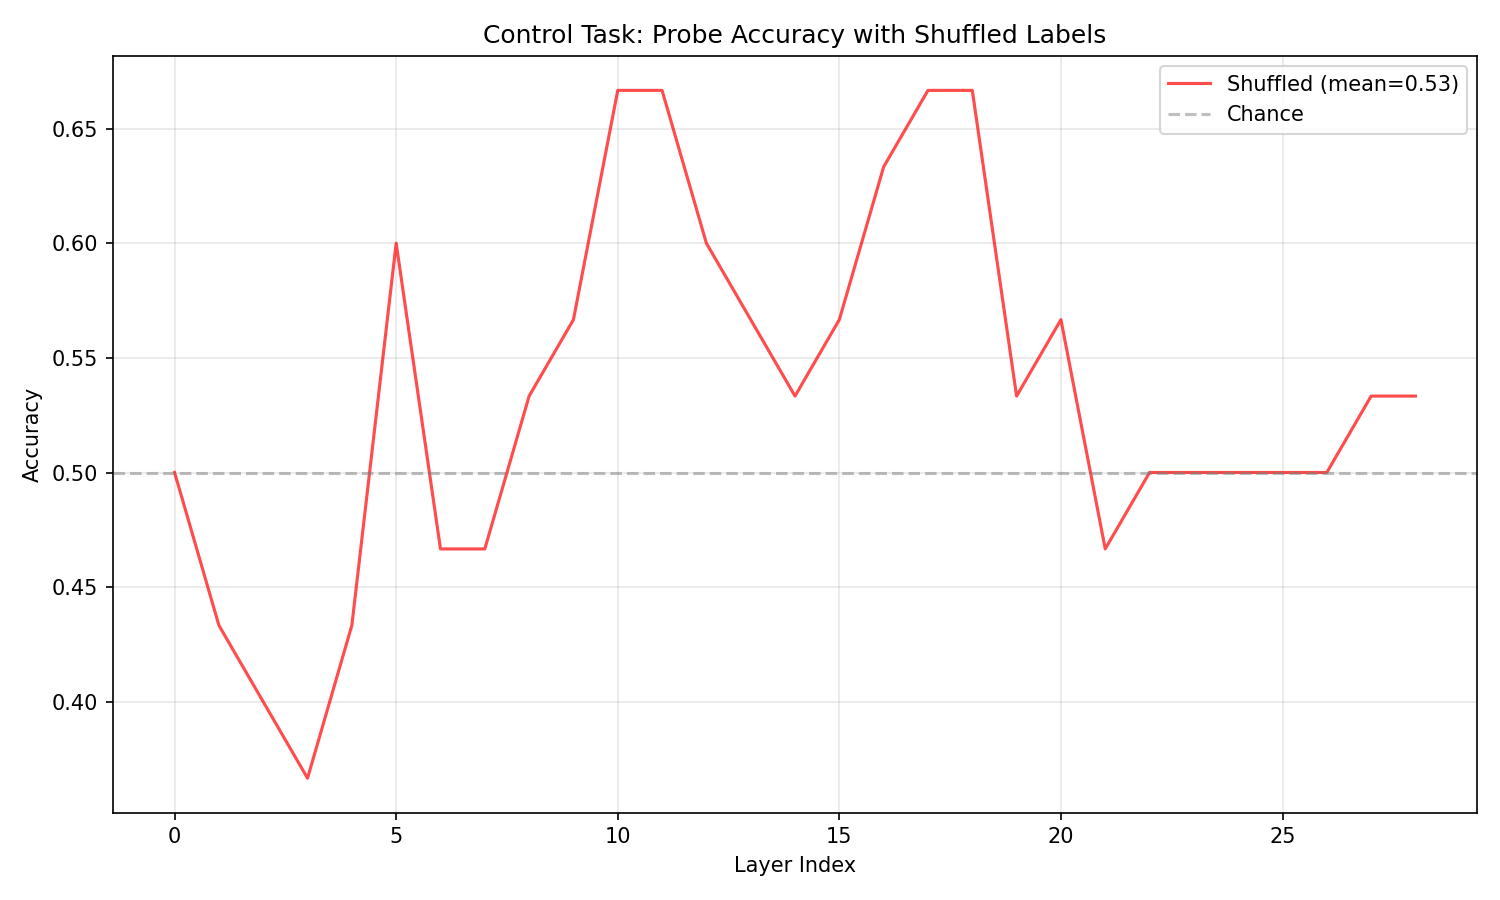


difficulty_probe_classification.png:


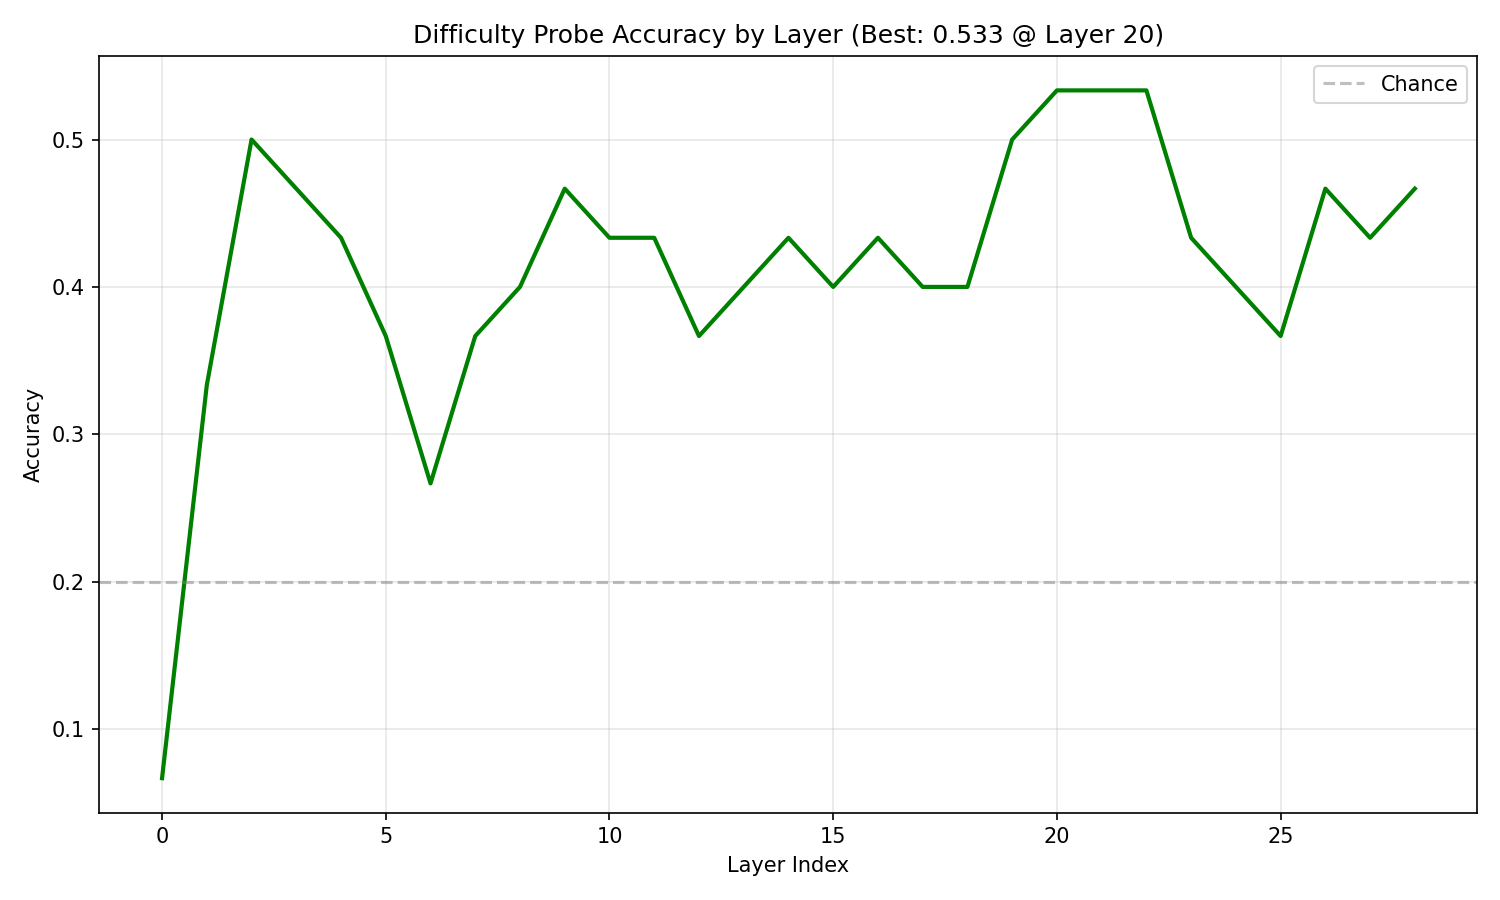


difficulty_probe_regression.png:


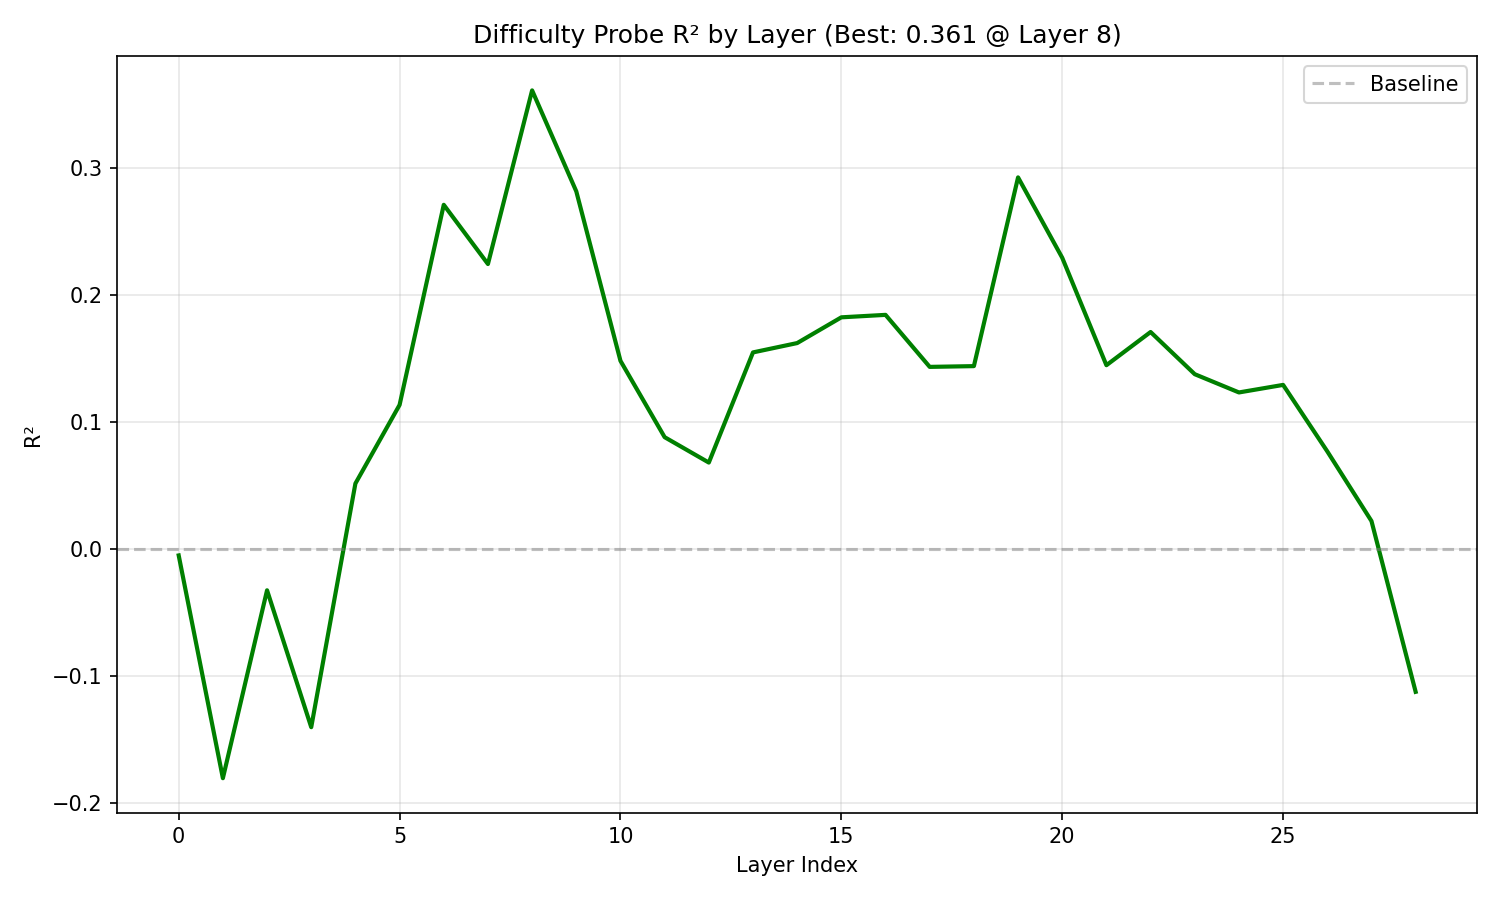


pca_layer20_correctness.png:


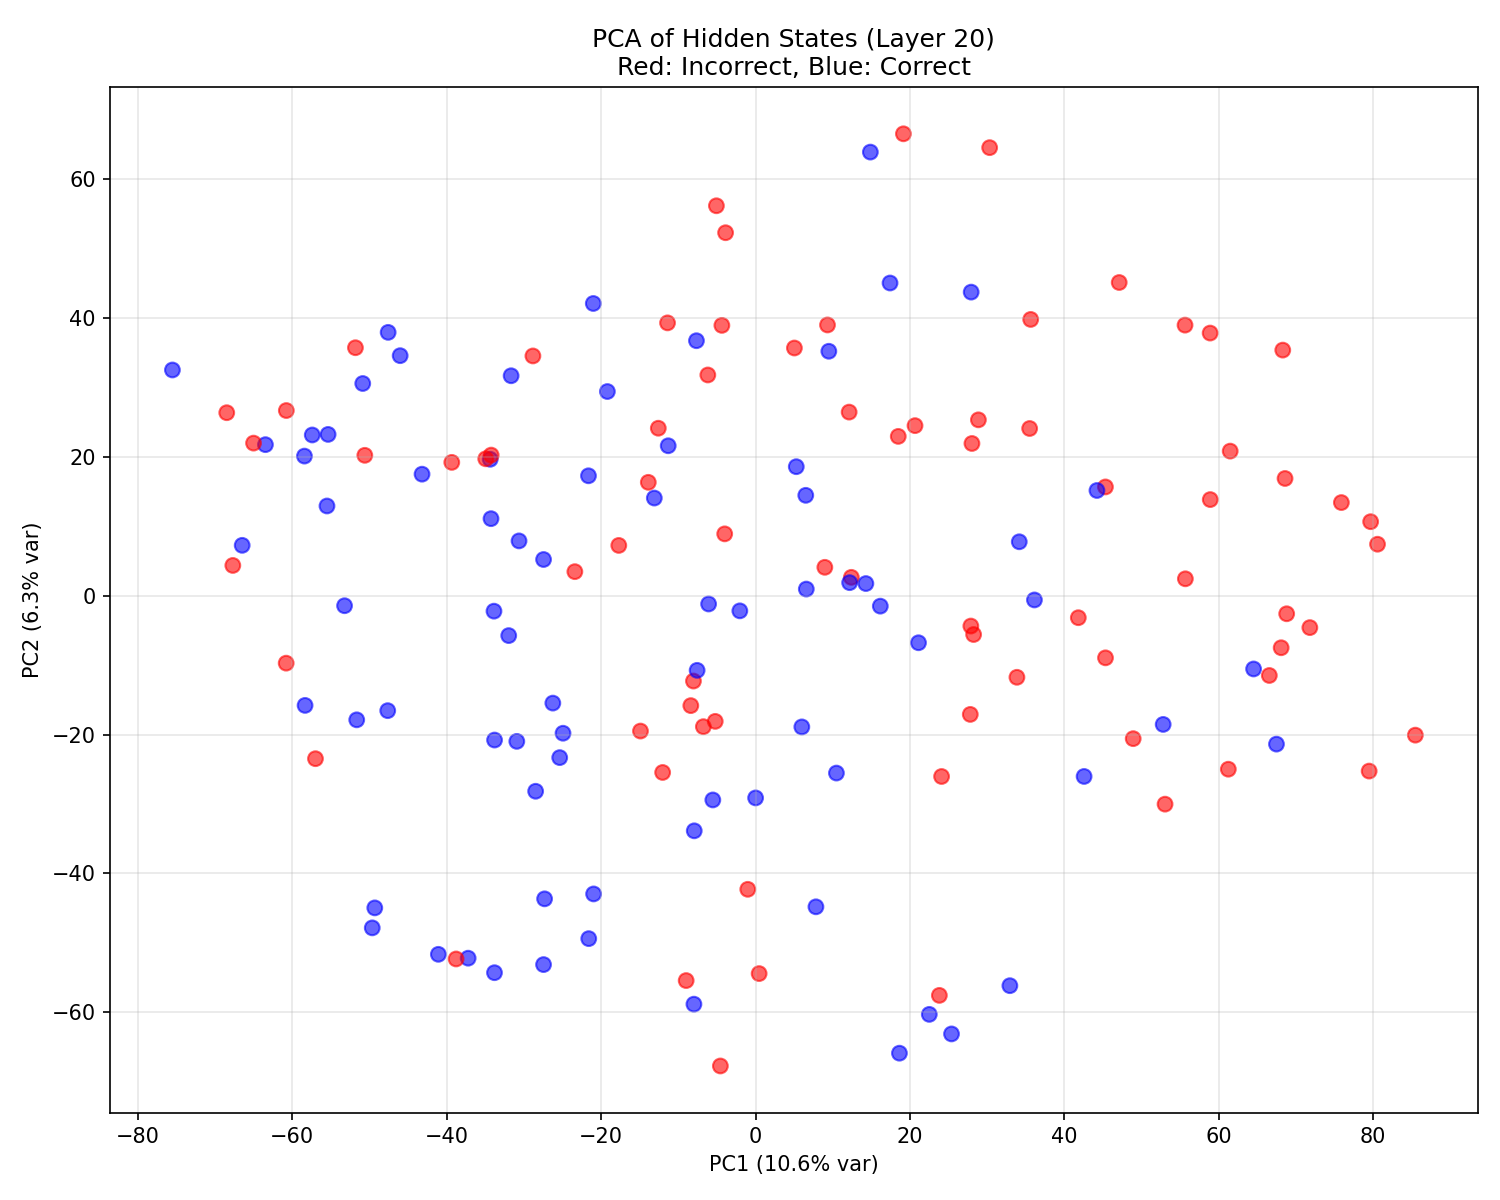


pca_layer20_difficulty.png:


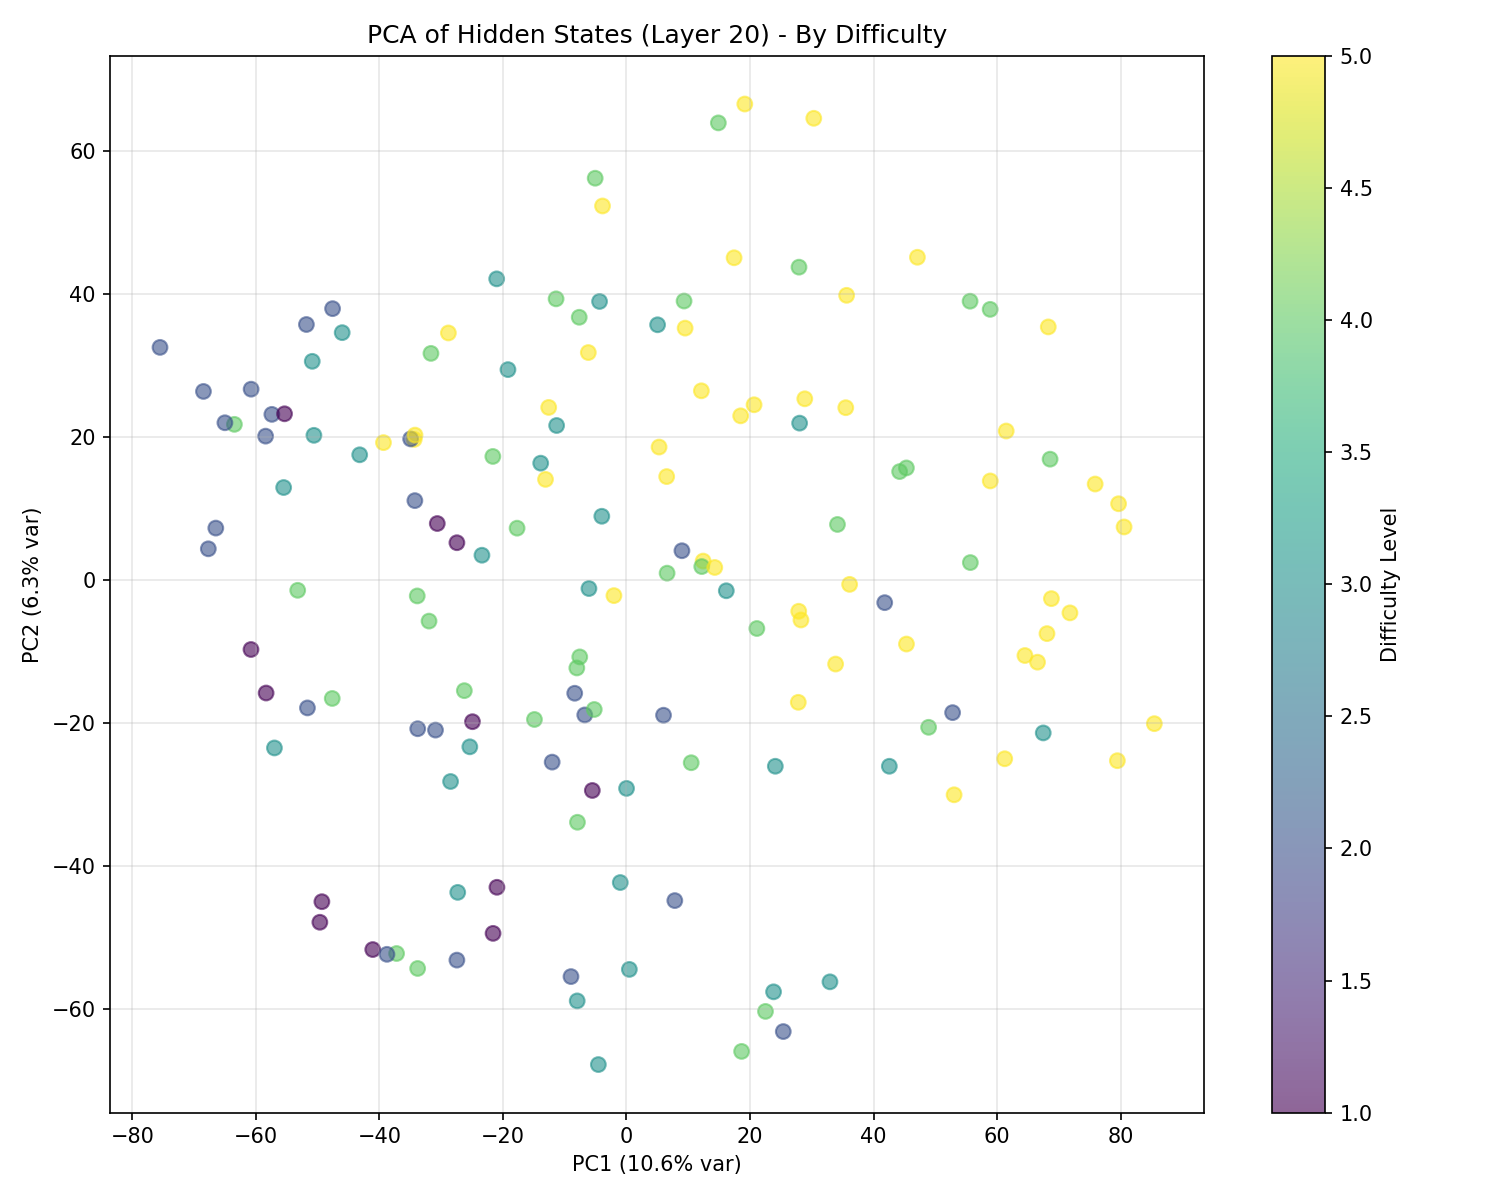


pca_layer20_topic.png:


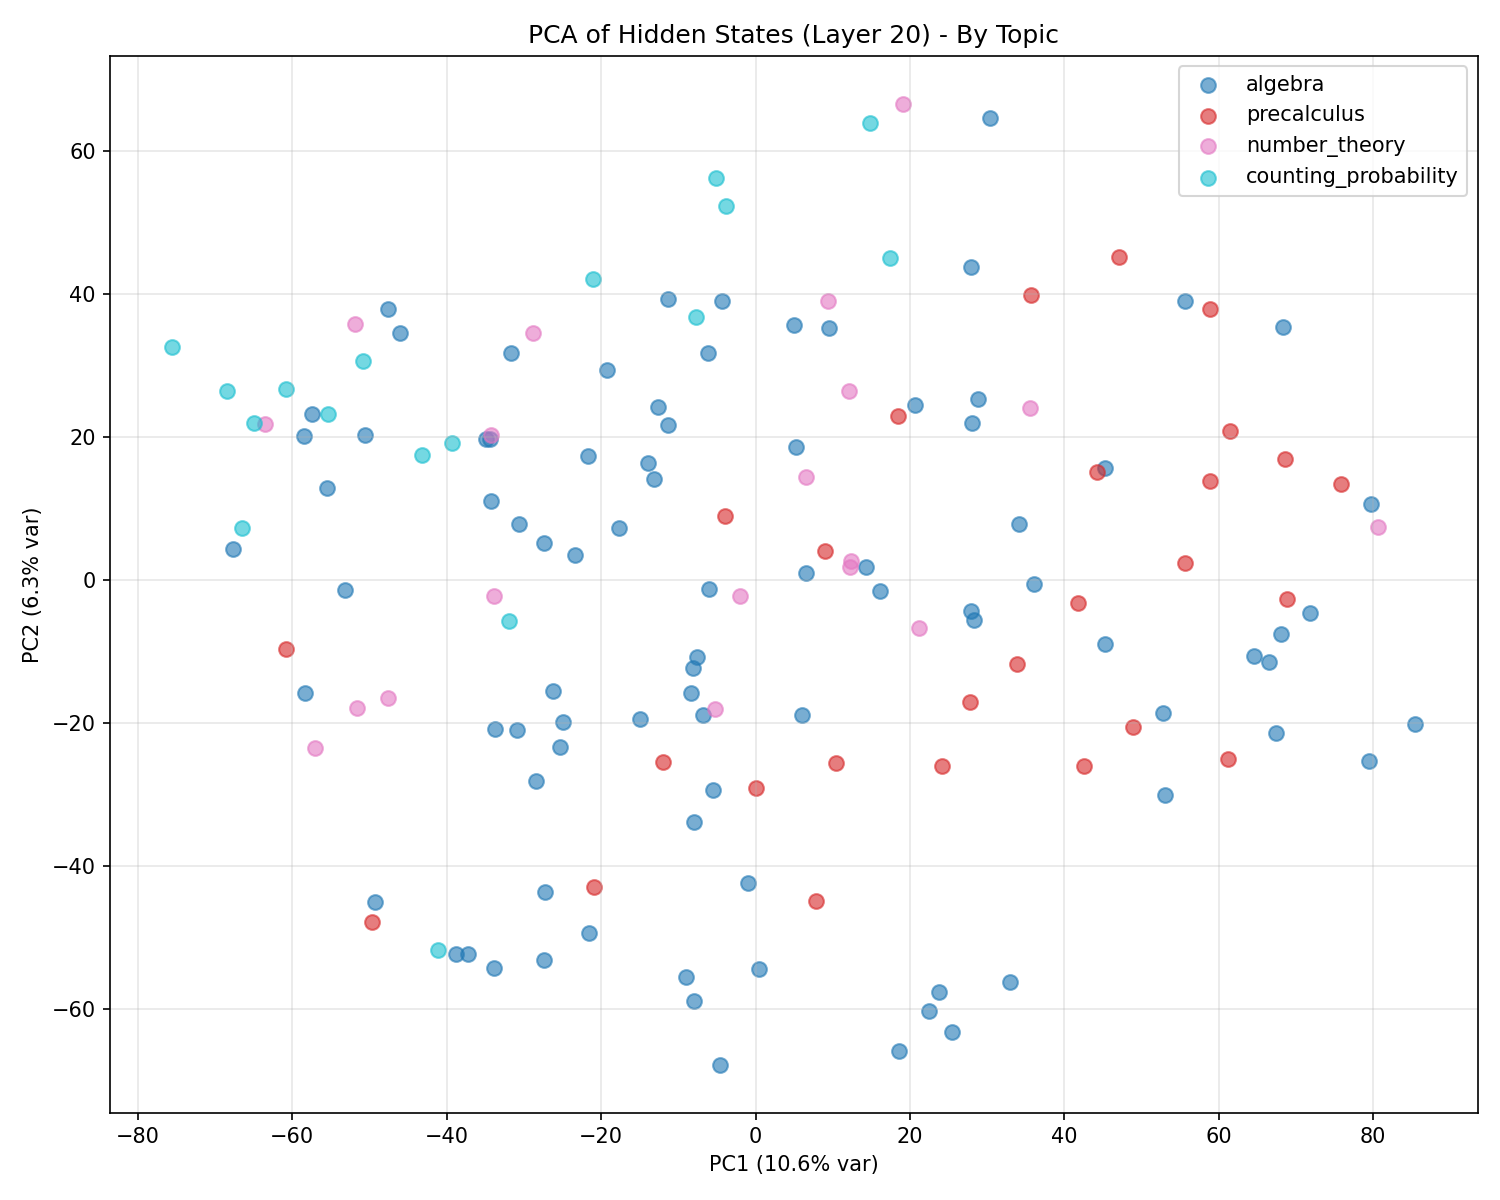


success_probe_accuracy.png:


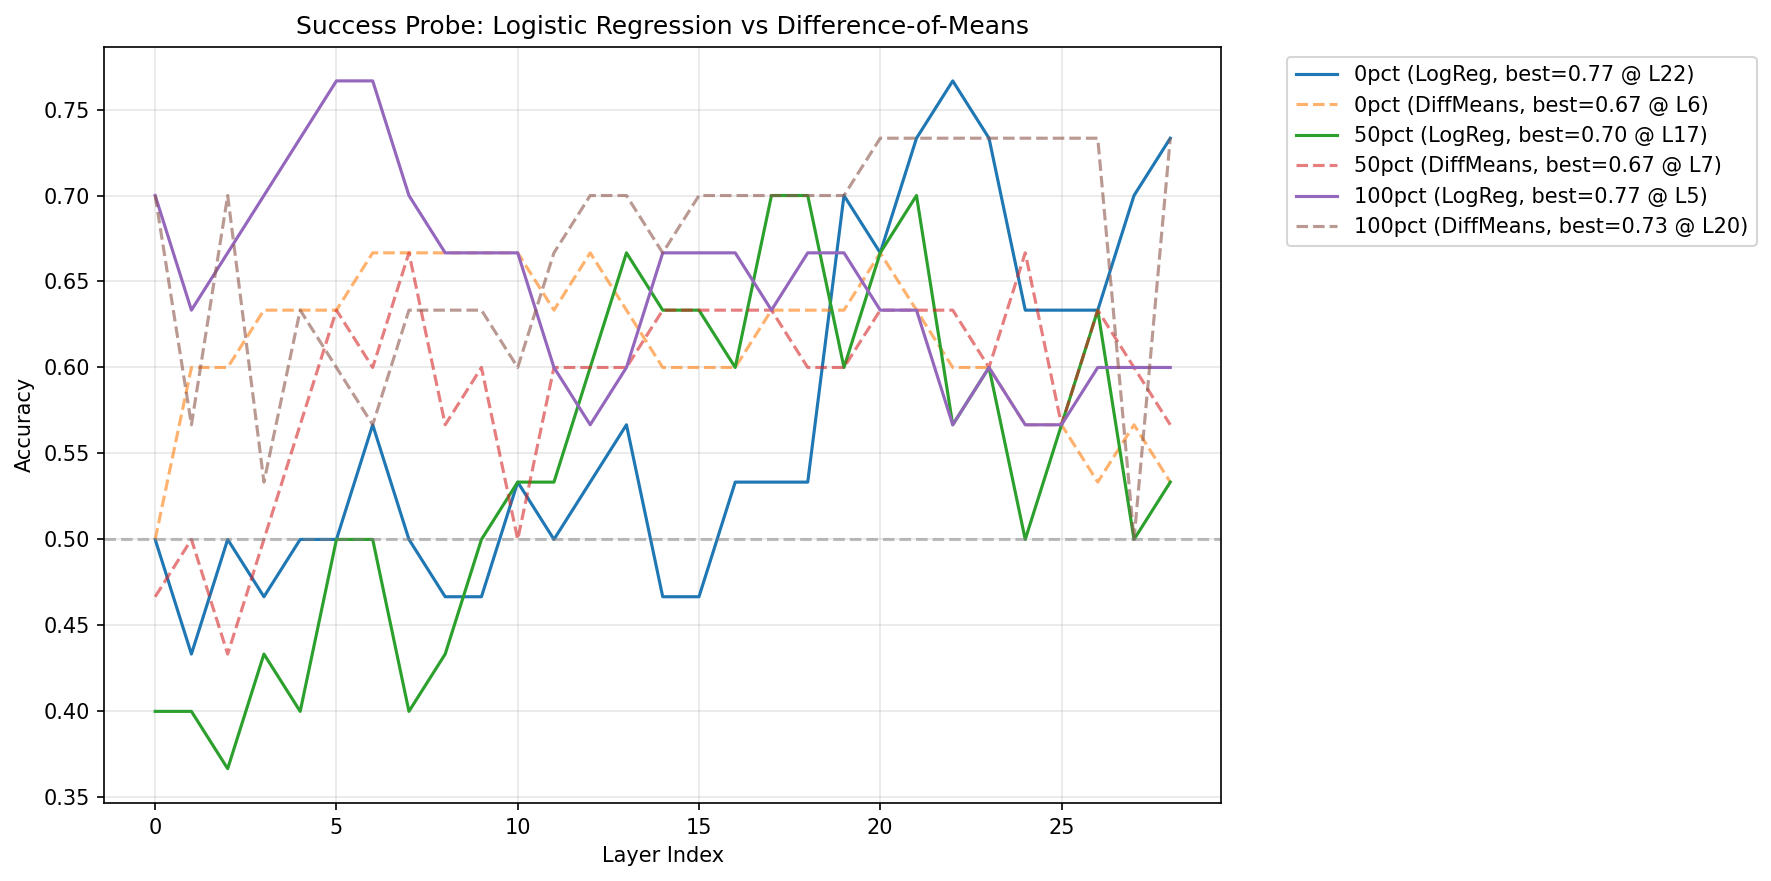


success_probe_heatmap_2d.png:


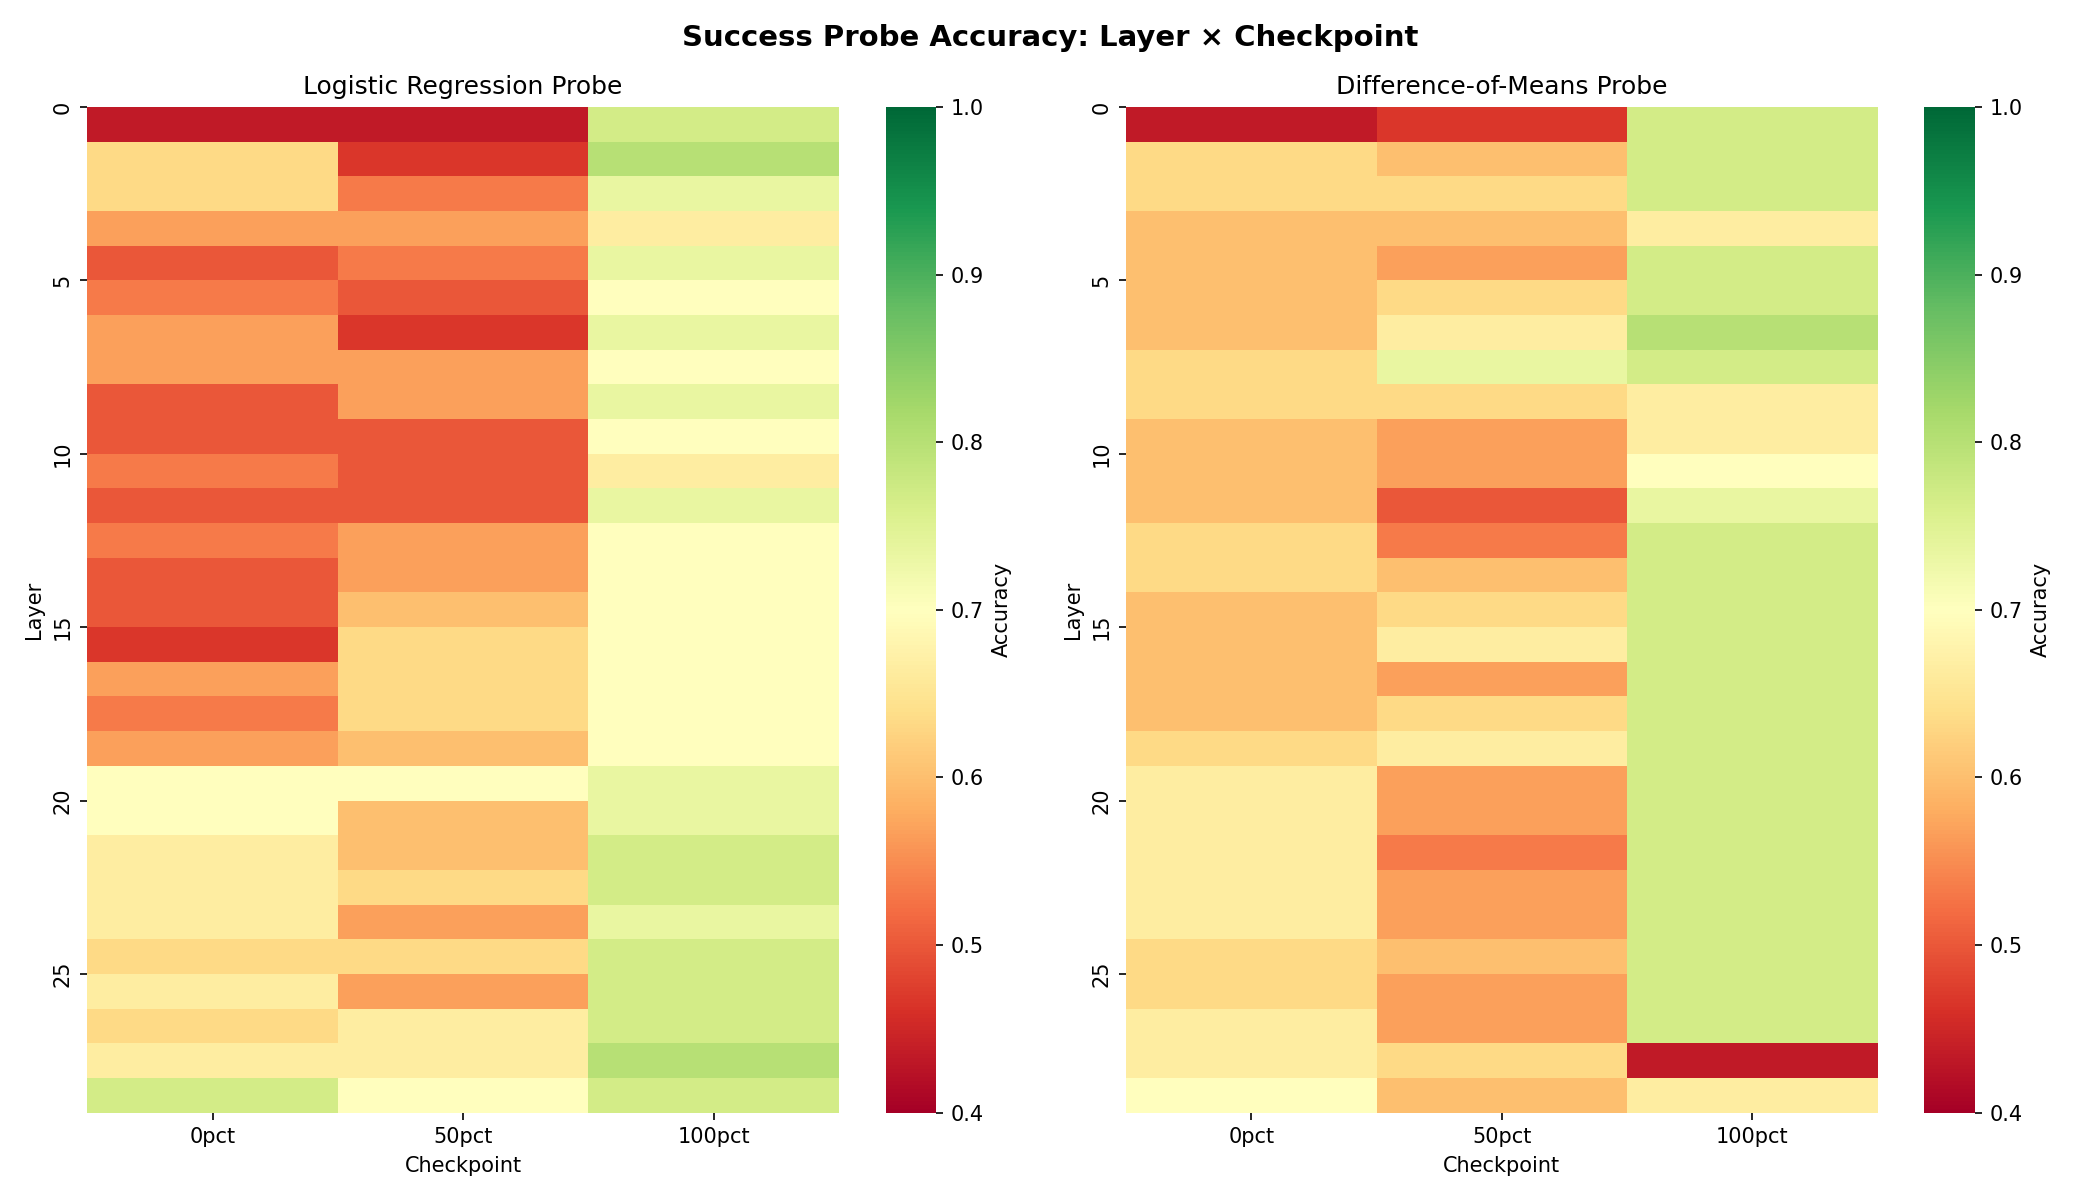


topic_probe_accuracy.png:


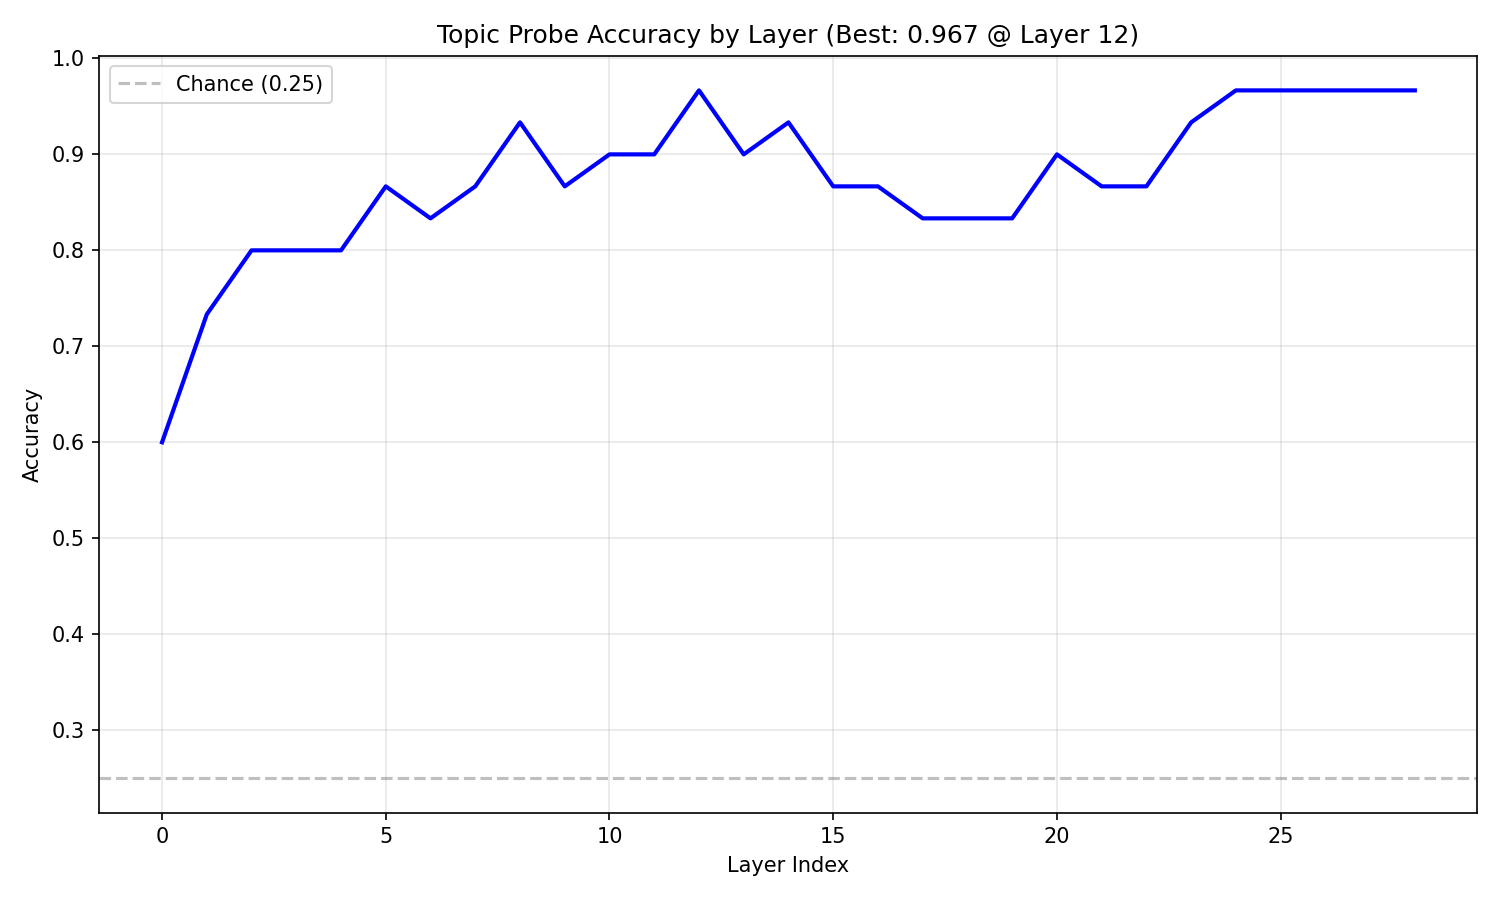


SUMMARY
  num_samples: 150
  num_layers: 29
  hidden_dim: 3584
  has_50pct: True
  success_0pct_logreg_best: 0.7666666666666667
  success_0pct_diff_best: 0.6666666666666666
  success_50pct_logreg_best: 0.7
  success_50pct_diff_best: 0.6666666666666666
  success_100pct_logreg_best: 0.7666666666666667
  success_100pct_diff_best: 0.7333333333333333
  topic_0pct_best_layer: 12
  topic_0pct_best_score: 0.9666666666666667
  difficulty_class_0pct_best_layer: 20
  difficulty_class_0pct_best_score: 0.5333333333333333
  difficulty_regress_0pct_best_layer: 8
  difficulty_regress_0pct_best_score: 0.36086996337786914


In [24]:
# Display probe results
from IPython.display import Image, display
import os

results_dir = "probe_results"

# Show all plots
for f in sorted(os.listdir(results_dir)):
    if f.endswith('.png'):
        print(f"\n{f}:")
        display(Image(filename=f"{results_dir}/{f}"))

# Show summary
import json
with open(f"{results_dir}/summary.json") as f:
    summary = json.load(f)

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
for k, v in summary.items():
    print(f"  {k}: {v}")

In [11]:
# # FIRST MINI RUN
# # 1. Collect probe data (with all metadata)
# !python probing-llm-math/src/collect_probe_data.py \
#     --num_samples 10 \
#     --dataset math \
#     --balance \
#     --output_file probe_data.pt

# # 2. Train all probes
# !python probing-llm-math/src/train_probe.py \
#     --data_file probe_data.pt \
#     --output_dir probe_results

# # 3. Generate heatmap (separate run, more samples)
# !python probing-llm-math/src/stratified_eval.py \
#     --samples_per_cell 5 \
#     --output_dir eval_results

In [12]:
# import os
# from IPython.display import Image, display

# print("--- Evaluation Results ---")
# result_dir = "eval_results"

# # Print summary.txt content
# summary_path = os.path.join(result_dir, "summary.txt")
# if os.path.exists(summary_path):
#     with open(summary_path, "r") as f:
#         summary_text = f.read()
#     print(summary_text)
# else:
#     print(f"(summary not found at {summary_path})")

# # Visualize heatmap
# heatmap_path = os.path.join(result_dir, "accuracy_heatmap.png")
# if os.path.exists(heatmap_path):
#     print("Displaying accuracy heatmap:")
#     display(Image(filename=heatmap_path))
# else:
#     print(f"(heatmap not found at {heatmap_path})")

# # Optionally confirm number of results
# results_pt_path = os.path.join(result_dir, "results.pt")
# if os.path.exists(results_pt_path):
#     print(f"\nSaved results file exists: {results_pt_path}")
# else:
#     print("(results.pt not found)")



In [13]:
# # 2. Train Probes & Analyze

# !python3 probing-llm-math/src/train_probe.py

In [14]:
# # 3. Visualize Results
# from IPython.display import Image, display
# import os

# results_dir = "probe_results"
# if os.path.exists(results_dir):
#     print("Probe Accuracy by Layer:")
#     display(Image(filename=f"{results_dir}/probe_accuracy.png"))

#     # Check for PCA plot (might vary by layer index)
#     pca_files = [f for f in os.listdir(results_dir) if f.startswith("pca_layer")]
#     if pca_files:
#         print("PCA Visualization:")
#         display(Image(filename=f"{results_dir}/{pca_files[0]}"))
# else:
#     print("No results found. Did the training script run successfully?")